In [1]:
# import libraries
import cv2 as cv
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# load images
eyes = cv.imread('../images/ojos/ho001.jpg', cv.IMREAD_GRAYSCALE)
mouth = cv.imread('../images/boca/hb001.jpg', cv.IMREAD_GRAYSCALE)
nose = cv.imread('../images/nariz/hn001.jpg', cv.IMREAD_GRAYSCALE)

# Resize images to the same size centered in the middle of the image
size = (350, 350)
def resize_image(image, size):
    h, w = image.shape
    new_image = np.zeros(size, dtype=np.uint8)
    x_offset = (size[1] - w) // 2
    y_offset = (size[0] - h) // 2
    new_image[y_offset:y_offset + h, x_offset:x_offset + w] = image
    return new_image

eyes = resize_image(eyes, size)
mouth = resize_image(mouth, size)
nose = resize_image(nose, size)


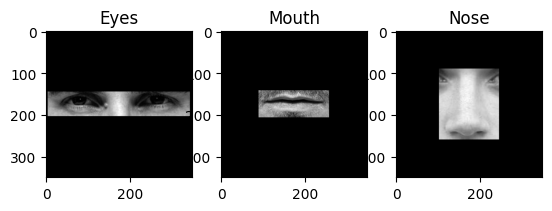

In [3]:
# Show images in space domain
plt.subplot(1, 3, 1), plt.imshow(eyes, cmap='gray'), plt.title('Eyes')
plt.subplot(1, 3, 2), plt.imshow(mouth, cmap='gray'), plt.title('Mouth')
plt.subplot(1, 3, 3), plt.imshow(nose, cmap='gray'), plt.title('Nose')
plt.show()


In [4]:
f_eyes = np.fft.fft2(eyes)
f_mouth = np.fft.fft2(mouth)
f_nose = np.fft.fft2(nose)

fs_eyes = np.fft.fftshift(f_eyes)
fs_mouth = np.fft.fftshift(f_mouth)
fs_nose = np.fft.fftshift(f_nose)

ms_eyes = 20 * np.log(np.abs(fs_eyes))
ms_mouth = 20 * np.log(np.abs(fs_mouth))
ms_nose = 20 * np.log(np.abs(fs_nose))

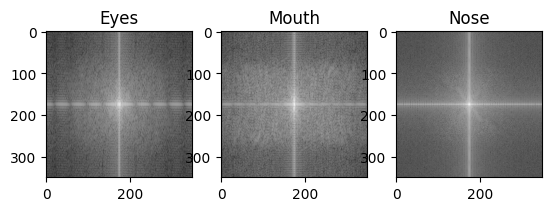

In [5]:
# Show images in frequency domain
plt.subplot(1, 3, 1), plt.imshow(ms_eyes, cmap='gray'), plt.title('Eyes')
plt.subplot(1, 3, 2), plt.imshow(ms_mouth, cmap='gray'), plt.title('Mouth')
plt.subplot(1, 3, 3), plt.imshow(ms_nose, cmap='gray'), plt.title('Nose')
plt.show()

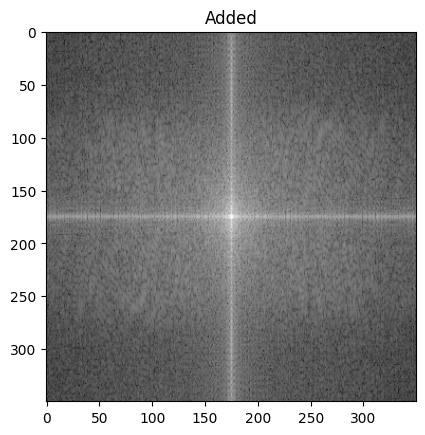

In [6]:
# add images in frequency domain
added = fs_eyes + fs_mouth + fs_nose
# Show added image in frequency domain
ms_added = 20 * np.log(np.abs(added))
plt.imshow(ms_added, cmap='gray'), plt.title('Added')
plt.show()

In [ ]:
# identify and separate the added images in space domain


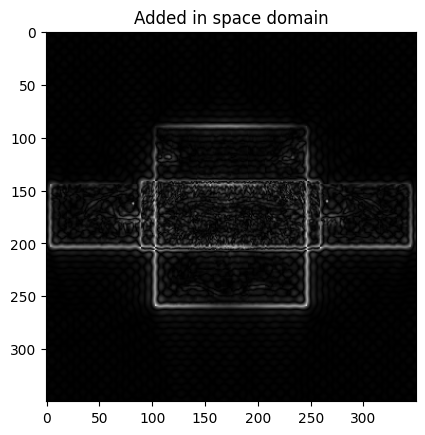

In [7]:
# highpass filter to added images
rows, cols = added.shape
crow, ccol = rows // 2 , cols // 2
mask = np.ones((rows, cols), np.uint8)
r = 30
center = [crow, ccol]
x, y = np.ogrid[:rows, :cols]
mask_area = (x - center[0]) ** 2 + (y - center[1]) ** 2 <= r*r
mask[mask_area] = 0
# Apply mask and inverse DFT
fshift = added * mask
f_ishift = np.fft.ifftshift(fshift)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)
# Show added image in space domain
plt.imshow(img_back, cmap='gray'), plt.title('Added in space domain')
plt.show()